# Filtros en el dominio frecuencial para detección de bordes — Comparativa visual

## 📘 OBJETIVO
Aplicar y visualizar diferentes filtros en el dominio frecuencial sobre una misma imagen, mostrando paso a paso el efecto de cada uno para resaltar bordes y obtener un resultado similar a un retrato dibujado a mano.

---

## 🔧 Configuración inicial

In [1]:
# Importar librerías necesarias
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.ndimage import gaussian_filter
from skimage import data, filters
from skimage.color import rgb2gray
import warnings

# Silenciar advertencias para visualización limpia
warnings.filterwarnings('ignore')

# Configurar matplotlib para mejor visualización
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

print("✅ Librerías importadas correctamente")

ModuleNotFoundError: No module named 'scipy'

## 📸 Cargar imagen de prueba

Usaremos una imagen de rostro incluida en scikit-image. Si prefieres usar tu propia imagen, modifica la ruta en la celda siguiente.

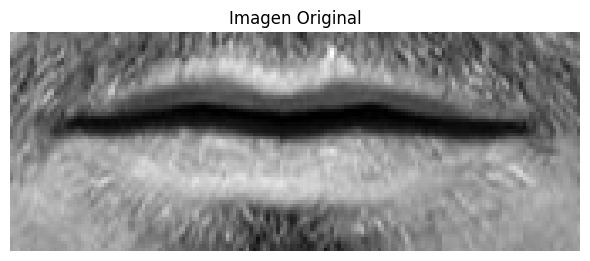

📐 Dimensiones de la imagen: (65, 169)


In [2]:
# Opción 1: Usar imagen de ejemplo de skimage
# imagen_original = data.camera()  # Imagen clásica de prueba
imagen_original = cv2.imread("images/boca/hb001.jpg", cv2.IMREAD_GRAYSCALE)

# Opción 2: Cargar tu propia imagen (descomenta y modifica la ruta)
# imagen_original = cv2.imread('ruta/a/tu/imagen.jpg', cv2.IMREAD_GRAYSCALE)

# Asegurar que la imagen sea de tipo float para procesamiento
imagen = imagen_original.astype(np.float32)

# Mostrar imagen original
plt.figure(figsize=(6, 6))
plt.imshow(imagen, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"📐 Dimensiones de la imagen: {imagen.shape}")

## 🛠️ Función genérica para visualizar etapas

Esta función muestra:
1. Imagen original
2. Espectro de Fourier (magnitud en escala logarítmica)
3. Filtro aplicado
4. Espectro filtrado
5. Imagen resultante
6. Bordes binarizados

In [3]:
def mostrar_etapas(imagen, filtro_nombre, filtro_H, umbral=50):
    """
    Visualiza las etapas del filtrado en el dominio frecuencial.
    
    Args:
        imagen: Imagen en escala de grises (np.ndarray)
        filtro_nombre: Nombre descriptivo del filtro (str)
        filtro_H: Filtro en el dominio frecuencial (np.ndarray)
        umbral: Umbral para binarización final (int)
    """
    # 1. Calcular FFT de la imagen
    f = np.fft.fft2(imagen)
    fshift = np.fft.fftshift(f)  # Centrar el espectro
    
    # 2. Calcular magnitud del espectro (escala logarítmica para visualización)
    magnitud_espectro = 20 * np.log(np.abs(fshift) + 1)
    
    # 3. Aplicar filtro en el dominio frecuencial
    fshift_filtrado = fshift * filtro_H
    magnitud_filtrada = 20 * np.log(np.abs(fshift_filtrado) + 1)
    
    # 4. Transformada inversa para obtener imagen filtrada
    f_ishift = np.fft.ifftshift(fshift_filtrado)
    img_filtrada = np.fft.ifft2(f_ishift)
    img_filtrada = np.abs(img_filtrada)
    
    # 5. Normalizar para visualización
    img_normalizada = cv2.normalize(img_filtrada, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # 6. Binarizar para obtener bordes nítidos (fondo blanco, bordes negros)
    _, img_binaria = cv2.threshold(img_normalizada, umbral, 255, cv2.THRESH_BINARY)
    img_binaria = cv2.bitwise_not(img_binaria)
    
    # Visualización en cuadrícula 2x3
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Fila 1: Original, Espectro, Filtro
    axes[0, 0].imshow(imagen, cmap='gray')
    axes[0, 0].set_title('1. Imagen Original')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(magnitud_espectro, cmap='gray')
    axes[0, 1].set_title('2. Espectro de Fourier (log)')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(filtro_H, cmap='gray')
    axes[0, 2].set_title(f'3. Filtro: {filtro_nombre}')
    axes[0, 2].axis('off')
    
    # Fila 2: Espectro filtrado, Resultado, Bordes binarizados
    axes[1, 0].imshow(magnitud_filtrada, cmap='gray')
    axes[1, 0].set_title('4. Espectro Filtrado (log)')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(img_normalizada, cmap='gray')
    axes[1, 1].set_title('5. Imagen Filtrada')
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(img_binaria, cmap='gray')
    axes[1, 2].set_title('6. Bordes Binarizados')
    axes[1, 2].axis('off')
    
    plt.suptitle(f'Filtro: {filtro_nombre}', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    return img_binaria

print("✅ Función mostrar_etapas() definida")

✅ Función mostrar_etapas() definida


## 🧮 Función auxiliar: Calcular distancia desde el centro

Esta función es fundamental para crear filtros radiales en el dominio frecuencial.

In [4]:
def distancia_desde_centro(shape):
    """
    Calcula la matriz de distancias desde el centro de la imagen.
    
    Args:
        shape: Tupla (rows, cols) con las dimensiones de la imagen
    
    Returns:
        Matriz de distancias D(u,v) donde cada elemento es la distancia
        euclídea desde el centro (crow, ccol)
    """
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    
    # Crear matrices de coordenadas
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u - crow, v - ccol, indexing='ij')
    
    # Calcular distancia euclídea: D(u,v) = sqrt((u-crow)^2 + (v-ccol)^2)
    D = np.sqrt(u**2 + v**2)
    
    return D

print("✅ Función distancia_desde_centro() definida")

✅ Función distancia_desde_centro() definida


---

# 🧩 FILTROS EN EL DOMINIO FRECUENCIAL

## 1️⃣ Ideal High-Pass Filter

**Fórmula:**
$$H(u,v) = \begin{cases} 
0 & \text{si } D(u,v) \leq D_0 \\
1 & \text{si } D(u,v) > D_0
\end{cases}$$

**Descripción:** Bloquea completamente las bajas frecuencias (centro del espectro) y deja pasar las altas frecuencias. Es el filtro más simple pero produce efecto de "ringing" (anillos) en los bordes.

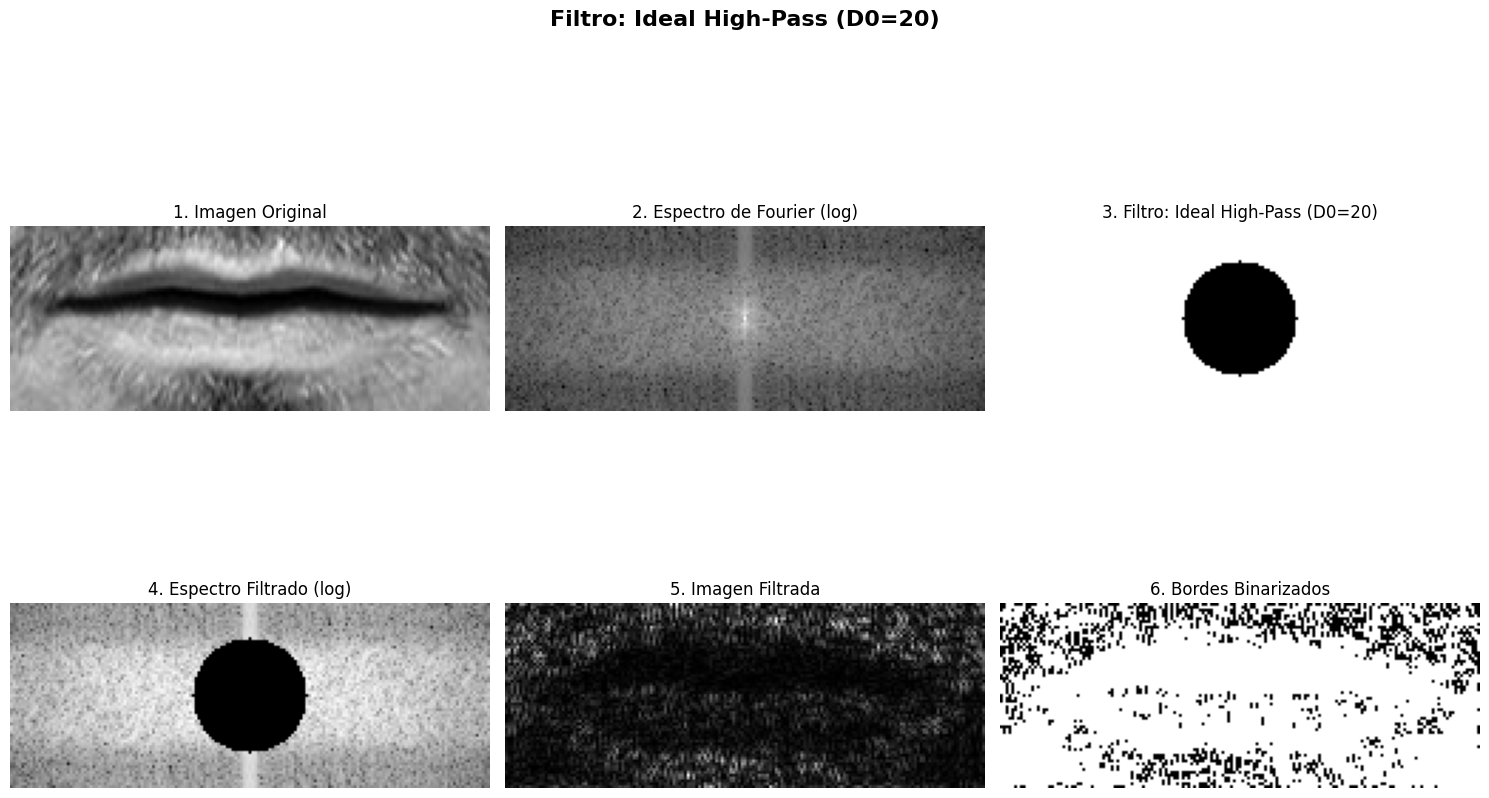

In [6]:
# Parámetros del filtro
D0 = 20  # Radio de corte

# Calcular distancias
D = distancia_desde_centro(imagen.shape)

# Crear filtro ideal pasa altas
H_ideal = np.where(D <= D0, 0, 1).astype(np.float32)

# Aplicar y visualizar
resultado_ideal = mostrar_etapas(imagen, f'Ideal High-Pass (D0={D0})', H_ideal, umbral=50)

## 2️⃣ Butterworth High-Pass Filter

**Fórmula:**
$$H(u,v) = \frac{1}{1 + \left(\frac{D_0}{D(u,v)}\right)^{2n}}$$

**Descripción:** Transición suave entre frecuencias bloqueadas y permitidas. El parámetro `n` (orden) controla la pendiente de la transición. Reduce el ringing comparado con el filtro ideal.

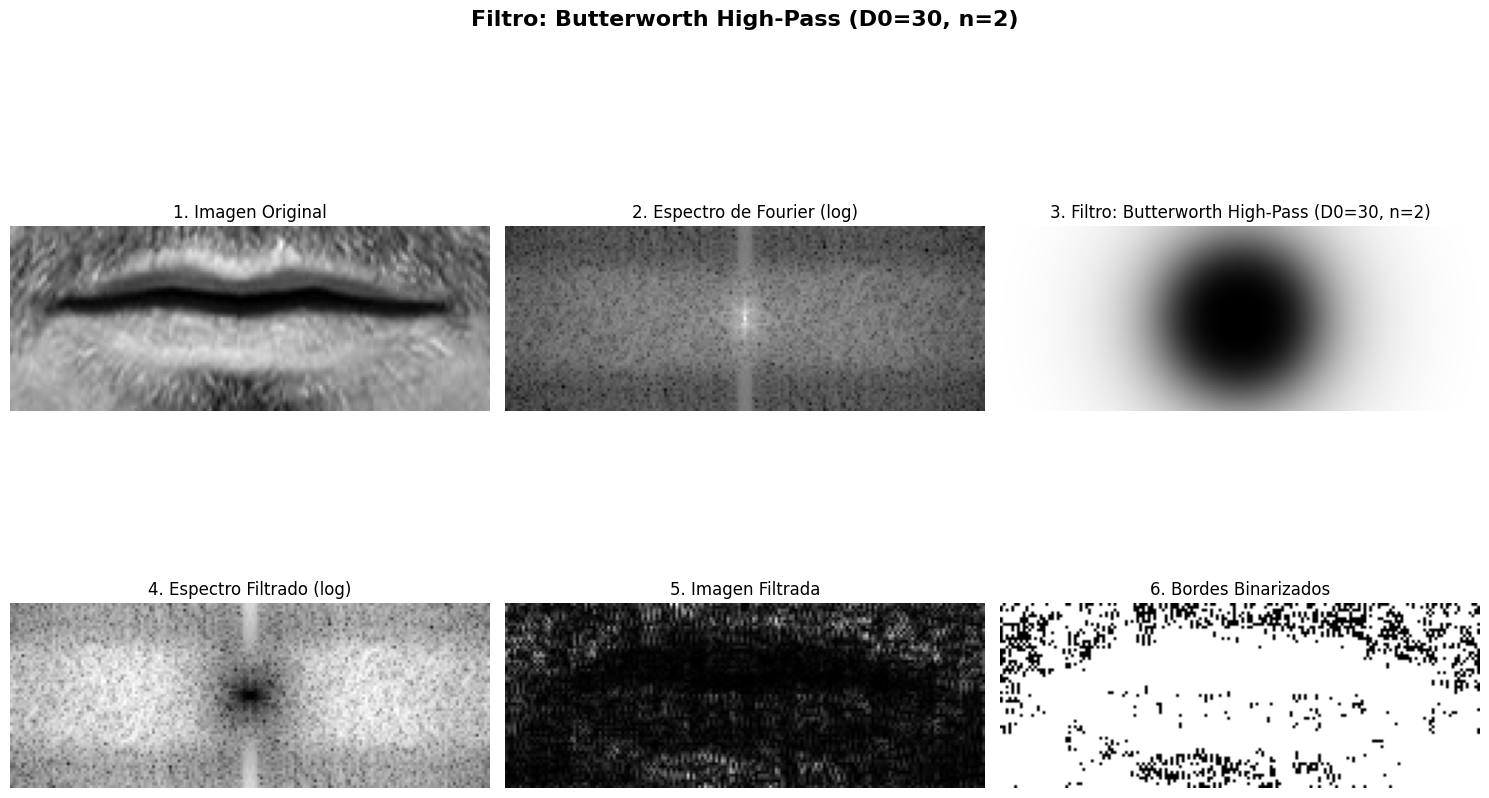

In [7]:
# Parámetros del filtro
D0 = 30  # Radio de corte
n = 2    # Orden del filtro

# Calcular distancias
D = distancia_desde_centro(imagen.shape)

# Crear filtro Butterworth pasa altas
# Evitar división por cero
D[D == 0] = 1e-10
H_butterworth = 1 / (1 + (D0 / D)**(2 * n))

# Aplicar y visualizar
resultado_butterworth = mostrar_etapas(imagen, f'Butterworth High-Pass (D0={D0}, n={n})', H_butterworth, umbral=50)

## 3️⃣ Gaussian High-Pass Filter

**Fórmula:**
$$H(u,v) = 1 - e^{-\frac{D(u,v)^2}{2D_0^2}}$$

**Descripción:** Transición muy suave, sin ringing. Ideal para preservar la información de los bordes sin artefactos. Es el filtro más usado en aplicaciones prácticas.

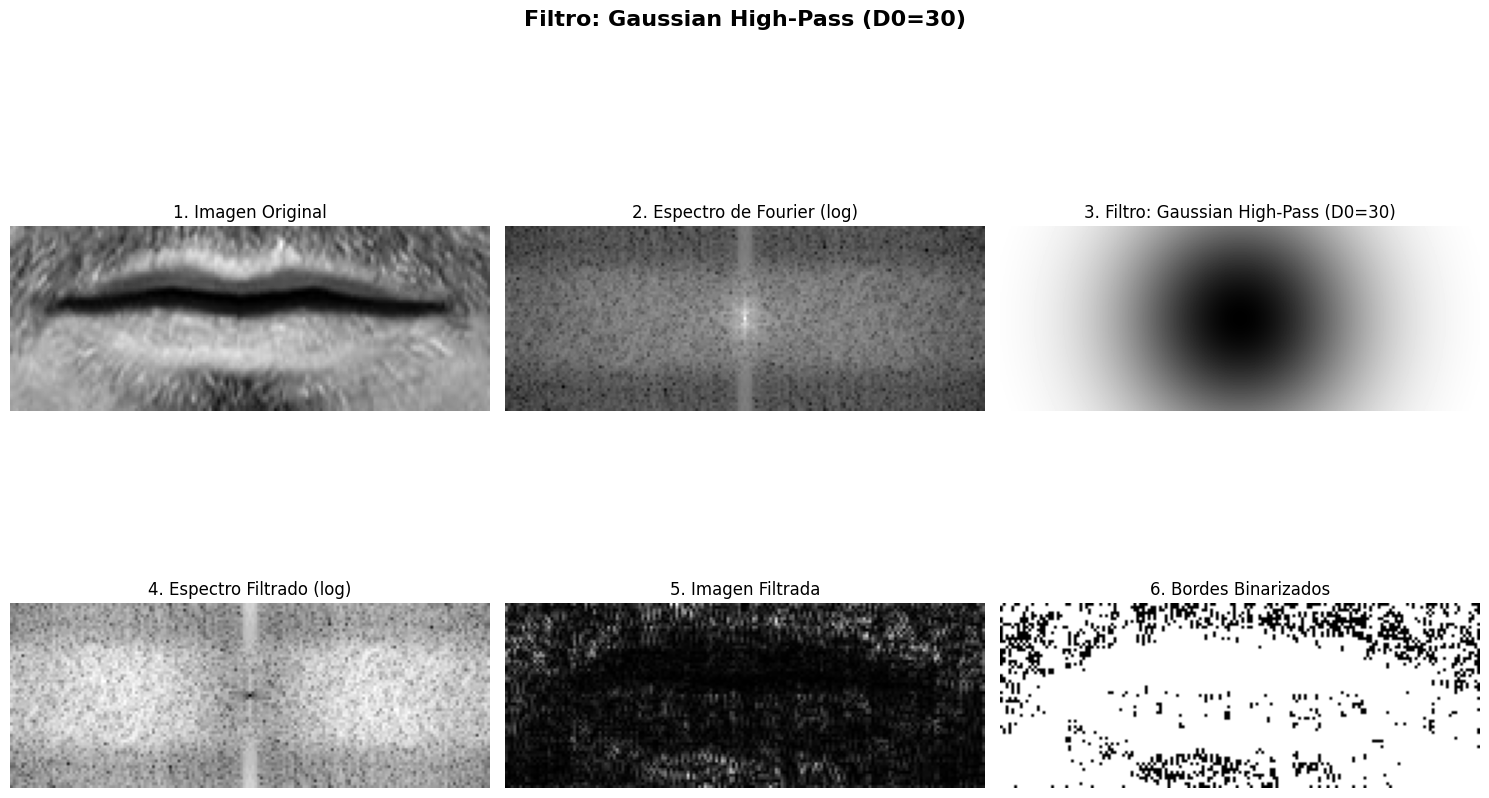

In [ ]:
# Parámetros del filtro
D0 = 10  # Radio de corte

# Calcular distancias
D = distancia_desde_centro(imagen.shape)

# Crear filtro Gaussiano pasa altas
H_gaussian = 1 - np.exp(-(D**2) / (2 * D0**2))

# Aplicar y visualizar
resultado_gaussian = mostrar_etapas(imagen, f'Gaussian High-Pass (D0={D0})', H_gaussian, umbral=50)

## 4️⃣ Laplaciano en Frecuencia

**Fórmula:**
$$H(u,v) = -4\pi^2(u^2 + v^2)$$

**Descripción:** El Laplaciano detecta cambios de intensidad en todas las direcciones. En el dominio frecuencial, es proporcional al cuadrado de la frecuencia. Resalta bordes y puntos aislados.

In [ ]:
# Calcular coordenadas centradas
rows, cols = imagen.shape
crow, ccol = rows // 2, cols // 2

u = np.arange(rows) - crow
v = np.arange(cols) - ccol
u, v = np.meshgrid(u, v, indexing='ij')

# Crear filtro Laplaciano: H(u,v) = -(u^2 + v^2)
H_laplacian = -(u**2 + v**2)

# Normalizar para visualización del filtro
H_laplacian_norm = cv2.normalize(H_laplacian, None, 0, 1, cv2.NORM_MINMAX)

# Aplicar y visualizar
resultado_laplacian = mostrar_etapas(imagen, 'Laplaciano en Frecuencia', H_laplacian_norm, umbral=30)

## 5️⃣ Laplaciano de Gaussiano (LoG)

**Fórmula:**
$$LoG(x,y) = -\frac{1}{\pi\sigma^4}\left[1 - \frac{x^2+y^2}{2\sigma^2}\right]e^{-\frac{x^2+y^2}{2\sigma^2}}$$

**Descripción:** Combina suavizado Gaussiano con el Laplaciano. Primero suaviza la imagen para reducir ruido, luego detecta bordes. Es muy efectivo para detectar bordes en imágenes ruidosas.

In [ ]:
# Parámetros
sigma = 2.0  # Desviación estándar del Gaussiano
size = 31    # Tamaño del kernel (debe ser impar)

# Crear kernel LoG en el dominio espacial
x = np.arange(-size//2 + 1, size//2 + 1)
y = np.arange(-size//2 + 1, size//2 + 1)
x, y = np.meshgrid(x, y)

# Fórmula del LoG
kernel_log = -(1 / (np.pi * sigma**4)) * (1 - (x**2 + y**2) / (2 * sigma**2)) * \
              np.exp(-(x**2 + y**2) / (2 * sigma**2))

# Expandir kernel al tamaño de la imagen con padding
kernel_padded = np.zeros(imagen.shape)
kernel_padded[:size, :size] = kernel_log

# FFT del kernel
H_log_fft = np.fft.fft2(kernel_padded)
H_log_fft = np.fft.fftshift(H_log_fft)

# Normalizar para visualización
H_log_vis = np.abs(H_log_fft)
H_log_vis = cv2.normalize(H_log_vis, None, 0, 1, cv2.NORM_MINMAX)

# Aplicar y visualizar
resultado_log = mostrar_etapas(imagen, f'Laplaciano de Gaussiano (σ={sigma})', H_log_vis, umbral=40)

## 6️⃣ Difference of Gaussians (DoG)

**Fórmula:**
$$DoG(x,y) = G_{\sigma_1}(x,y) - G_{\sigma_2}(x,y)$$

**Descripción:** Resta dos Gaussianos con diferentes σ. Aproxima el LoG pero es más eficiente computacionalmente. Usado en SIFT y otros detectores de características.

In [ ]:
# Parámetros
sigma1 = 1.0
sigma2 = 2.0

# Calcular distancias
D = distancia_desde_centro(imagen.shape)

# Crear dos filtros Gaussianos
G1 = np.exp(-(D**2) / (2 * sigma1**2))
G2 = np.exp(-(D**2) / (2 * sigma2**2))

# DoG = Diferencia de Gaussianos
H_dog = G1 - G2

# Normalizar para visualización
H_dog_norm = cv2.normalize(H_dog, None, 0, 1, cv2.NORM_MINMAX)

# Aplicar y visualizar
resultado_dog = mostrar_etapas(imagen, f'DoG (σ1={sigma1}, σ2={sigma2})', H_dog_norm, umbral=50)

## 7️⃣ Filtros Gabor

**Descripción:** Los filtros Gabor son excelentes para detectar bordes en orientaciones específicas. Son similares a las neuronas de la corteza visual humana. Combinaremos respuestas en múltiples orientaciones.

In [ ]:
# Parámetros
frecuencia = 0.1  # Frecuencia del filtro
orientaciones = [0, np.pi/4, np.pi/2, 3*np.pi/4]  # 0°, 45°, 90°, 135°

# Aplicar filtros Gabor en diferentes orientaciones
respuestas_gabor = []

for theta in orientaciones:
    # Usar skimage para aplicar el filtro Gabor
    real, imag = filters.gabor(imagen, frequency=frecuencia, theta=theta)
    magnitud = np.sqrt(real**2 + imag**2)
    respuestas_gabor.append(magnitud)

# Combinar respuestas: tomar el máximo en cada píxel
respuesta_combinada = np.maximum.reduce(respuestas_gabor)

# Normalizar
respuesta_normalizada = cv2.normalize(respuesta_combinada, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Binarizar
_, resultado_gabor = cv2.threshold(respuesta_normalizada, 50, 255, cv2.THRESH_BINARY)
resultado_gabor = cv2.bitwise_not(resultado_gabor)

# Visualizar el proceso
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(imagen, cmap='gray')
axes[0, 0].set_title('Imagen Original')
axes[0, 0].axis('off')

# Mostrar respuestas individuales
for idx, (resp, theta) in enumerate(zip(respuestas_gabor, orientaciones)):
    if idx < 4:
        ax = axes[(idx+1)//3, (idx+1)%3]
        ax.imshow(resp, cmap='gray')
        ax.set_title(f'Gabor θ={int(np.degrees(theta))}°')
        ax.axis('off')

axes[1, 2].imshow(resultado_gabor, cmap='gray')
axes[1, 2].set_title('Resultado Combinado')
axes[1, 2].axis('off')

plt.suptitle('Filtros Gabor Multi-orientación', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 8️⃣ Top-Hat (Filtro de Banda)

**Fórmula:**
$$H(u,v) = \begin{cases} 
1 & \text{si } D_1 < D(u,v) < D_2 \\
0 & \text{en otro caso}
\end{cases}$$

**Descripción:** Pasa solo las frecuencias en un rango específico (banda). Útil para extraer características de un tamaño particular o eliminar ruido en frecuencias específicas.

In [ ]:
# Parámetros del filtro
D1 = 20  # Radio interno
D2 = 60  # Radio externo

# Calcular distancias
D = distancia_desde_centro(imagen.shape)

# Crear filtro de banda (Band-Pass)
H_bandpass = np.where((D > D1) & (D < D2), 1, 0).astype(np.float32)

# Aplicar y visualizar
resultado_bandpass = mostrar_etapas(imagen, f'Band-Pass (D1={D1}, D2={D2})', H_bandpass, umbral=50)

---

# 🎨 COMPARATIVA FINAL

Ahora mostraremos todos los resultados binarizados en una sola cuadrícula para comparar visualmente.

In [ ]:
# Recolectar todos los resultados
resultados = [
    ('Original', imagen_original),
    ('Ideal HP', resultado_ideal),
    ('Butterworth HP', resultado_butterworth),
    ('Gaussian HP', resultado_gaussian),
    ('Laplaciano', resultado_laplacian),
    ('LoG', resultado_log),
    ('DoG', resultado_dog),
    ('Gabor Multi-θ', resultado_gabor),
    ('Band-Pass', resultado_bandpass)
]

# Crear cuadrícula 3x3
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

for idx, (nombre, imagen_resultado) in enumerate(resultados):
    axes[idx].imshow(imagen_resultado, cmap='gray')
    axes[idx].set_title(nombre, fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Comparativa de Filtros Frecuenciales para Detección de Bordes', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 📊 Análisis Comparativo

Analicemos cada filtro en términos de:
- **Nivel de detalle conservado**
- **Claridad de los contornos**
- **Similitud con dibujo a mano**

In [ ]:
print("="*80)
print("ANÁLISIS COMPARATIVO DE FILTROS")
print("="*80)
print()

analisis = [
    ("1. Ideal High-Pass", 
     "Bordes muy nítidos pero con ringing (artefactos en anillos).",
     "Contornos definidos pero con ruido artificial.",
     "Poco realista para dibujo a mano debido a artefactos."),
    
    ("2. Butterworth High-Pass",
     "Balance entre nitidez y suavidad, menos ringing que Ideal.",
     "Bordes claros con transición suave.",
     "Buena aproximación a boceto, natural y sin artefactos."),
    
    ("3. Gaussian High-Pass",
     "Transición muy suave, preserva detalles importantes.",
     "Contornos suaves y continuos.",
     "Excelente para bocetos realistas, estilo acuarela."),
    
    ("4. Laplaciano",
     "Detecta todos los cambios de intensidad, muy sensible.",
     "Bordes completos en todas direcciones, puede ser ruidoso.",
     "Estilo de boceto detallado, similar a lápiz fino."),
    
    ("5. Laplaciano de Gaussiano (LoG)",
     "Suavizado previo reduce ruido, bordes más limpios.",
     "Contornos bien definidos sin ruido excesivo.",
     "Muy bueno para retratos tipo sketch, equilibrado."),
    
    ("6. Difference of Gaussians (DoG)",
     "Similar a LoG, resalta bordes en múltiples escalas.",
     "Bordes naturales con buen contraste.",
     "Excelente para efecto dibujado a mano profesional."),
    
    ("7. Gabor Multi-orientación",
     "Captura texturas y bordes direccionales específicos.",
     "Bordes orientados, útil para características específicas.",
     "Estilo artístico único, resalta patrones direccionales."),
    
    ("8. Band-Pass (Top-Hat)",
     "Extrae solo detalles de tamaño medio.",
     "Contornos parciales, puede perder información.",
     "Útil para efectos estilizados o abstractos.")
]

for nombre, detalle, contorno, dibujo in analisis:
    print(f"\n{nombre}")
    print("-" * len(nombre))
    print(f"📌 Detalle: {detalle}")
    print(f"🎯 Contornos: {contorno}")
    print(f"✏️  Dibujo a mano: {dibujo}")

print("\n" + "="*80)
print("RECOMENDACIONES")
print("="*80)
print("\n🏆 Para retratos tipo 'retrato hablado':")
print("   → Gaussian High-Pass o Butterworth (transiciones suaves)")
print("   → LoG o DoG (balance entre detalle y limpieza)")
print("\n🎨 Para efectos artísticos:")
print("   → Gabor (texturas direccionales)")
print("   → Laplaciano (detalles finos)")
print("\n⚡ Para procesamiento rápido:")
print("   → Butterworth (buen balance calidad/velocidad)")
print()

---

# 💡 COMBINACIÓN DE FILTROS (OPCIONAL)

Experimentemos combinando filtros para obtener efectos tipo "sketch" más sofisticados.

## Combinación 1: Gaussian Blur + LoG

Primero suavizamos fuertemente la imagen, luego aplicamos LoG para obtener un efecto de dibujo simplificado.

In [ ]:
# Paso 1: Suavizado fuerte
img_suavizada = gaussian_filter(imagen, sigma=3.0)

# Paso 2: Aplicar LoG
sigma_log = 1.5
size = 31
x = np.arange(-size//2 + 1, size//2 + 1)
y = np.arange(-size//2 + 1, size//2 + 1)
x, y = np.meshgrid(x, y)

kernel_log = -(1 / (np.pi * sigma_log**4)) * (1 - (x**2 + y**2) / (2 * sigma_log**2)) * \
              np.exp(-(x**2 + y**2) / (2 * sigma_log**2))

kernel_padded = np.zeros(img_suavizada.shape)
kernel_padded[:size, :size] = kernel_log

H_log_fft = np.fft.fft2(kernel_padded)
H_log_fft = np.fft.fftshift(H_log_fft)
H_log_vis = np.abs(H_log_fft)
H_log_vis = cv2.normalize(H_log_vis, None, 0, 1, cv2.NORM_MINMAX)

resultado_combinado1 = mostrar_etapas(img_suavizada, 'Blur + LoG (Sketch Simplificado)', H_log_vis, umbral=30)

## Combinación 2: DoG + Band-Pass

Aplicamos DoG para detectar bordes, luego filtramos solo frecuencias medias para obtener un efecto más artístico.

In [ ]:
# Paso 1: Aplicar DoG
D = distancia_desde_centro(imagen.shape)
sigma1, sigma2 = 1.0, 2.5
G1 = np.exp(-(D**2) / (2 * sigma1**2))
G2 = np.exp(-(D**2) / (2 * sigma2**2))
H_dog = G1 - G2

# Paso 2: Combinar con Band-Pass
D1, D2 = 15, 70
H_bandpass = np.where((D > D1) & (D < D2), 1, 0).astype(np.float32)

# Filtro combinado
H_combinado = H_dog * H_bandpass
H_combinado_norm = cv2.normalize(H_combinado, None, 0, 1, cv2.NORM_MINMAX)

resultado_combinado2 = mostrar_etapas(imagen, 'DoG + Band-Pass (Artístico)', H_combinado_norm, umbral=40)

## Combinación 3: Gabor + Gaussian HP

Combinar múltiples orientaciones de Gabor con un pasa altas Gaussiano para un efecto de "pencil drawing" realista.

In [ ]:
# Aplicar Gabor multi-orientación
frecuencia = 0.15
orientaciones = [0, np.pi/6, np.pi/3, np.pi/2, 2*np.pi/3, 5*np.pi/6]
respuestas = []

for theta in orientaciones:
    real, imag = filters.gabor(imagen, frequency=frecuencia, theta=theta)
    magnitud = np.sqrt(real**2 + imag**2)
    respuestas.append(magnitud)

# Combinar respuestas
respuesta_gabor = np.maximum.reduce(respuestas)

# Aplicar Gaussian HP adicional
D = distancia_desde_centro(respuesta_gabor.shape)
D0 = 25
H_gaussian = 1 - np.exp(-(D**2) / (2 * D0**2))

# FFT y filtrado
f = np.fft.fft2(respuesta_gabor)
fshift = np.fft.fftshift(f)
fshift_filtrado = fshift * H_gaussian
f_ishift = np.fft.ifftshift(fshift_filtrado)
img_final = np.fft.ifft2(f_ishift)
img_final = np.abs(img_final)

# Normalizar y binarizar
img_final_norm = cv2.normalize(img_final, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
_, resultado_combinado3 = cv2.threshold(img_final_norm, 40, 255, cv2.THRESH_BINARY)
resultado_combinado3 = cv2.bitwise_not(resultado_combinado3)

# Visualizar
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(imagen, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_final_norm, cmap='gray')
plt.title('Gabor + Gaussian HP')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(resultado_combinado3, cmap='gray')
plt.title('Pencil Drawing Effect')
plt.axis('off')

plt.suptitle('Combinación Avanzada: Gabor Multi-θ + Gaussian HP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Comparativa de Combinaciones

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(imagen_original, cmap='gray')
axes[0, 0].set_title('Original', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(resultado_combinado1, cmap='gray')
axes[0, 1].set_title('Blur + LoG\n(Sketch Simplificado)', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(resultado_combinado2, cmap='gray')
axes[1, 0].set_title('DoG + Band-Pass\n(Artístico)', fontsize=14, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(resultado_combinado3, cmap='gray')
axes[1, 1].set_title('Gabor + Gaussian HP\n(Pencil Drawing)', fontsize=14, fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle('Combinaciones Avanzadas de Filtros', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---

# 🎓 CONCLUSIONES

## Resumen del Análisis

Hemos explorado 8 filtros diferentes en el dominio frecuencial y 3 combinaciones avanzadas:

### Filtros Básicos
1. **Ideal HP**: Simple pero con artefactos (ringing)
2. **Butterworth HP**: Balance óptimo entre suavidad y nitidez
3. **Gaussian HP**: Transición más suave, sin artefactos
4. **Laplaciano**: Detecta todos los cambios, muy sensible
5. **LoG**: Laplaciano suavizado, menos ruido
6. **DoG**: Eficiente, similar a LoG
7. **Gabor**: Orientación específica, útil para texturas
8. **Band-Pass**: Frecuencias medias, efecto estilizado

### Combinaciones Avanzadas
- **Blur + LoG**: Sketch simplificado y limpio
- **DoG + Band-Pass**: Efecto artístico controlado
- **Gabor + Gaussian HP**: Pencil drawing realista

### Para Retratos "Hablados"
Los mejores resultados se obtienen con:
- **Gaussian High-Pass** (bordes suaves y naturales)
- **Butterworth High-Pass** (buen balance)
- **LoG o DoG** (detalles limpios sin ruido)

### Ventajas del Dominio Frecuencial
- Control preciso sobre el rango de frecuencias
- Transiciones suaves sin artefactos
- Eficiente para imágenes grandes
- Base teórica sólida (teoría de Fourier)

---

**¡Experimento completado! 🎉**

Puedes modificar los parámetros (D0, n, sigma, umbral) en cada celda para explorar diferentes efectos.